## Лабораторная работа 3

## “RAG-поиск по корпусу научных публикаций”

Тематика для поиска: cs.SE (Software Engineering)

### Извлечение данных с arXiv API

In [119]:
%%capture
!pip install feedparser tqdm

In [120]:
import feedparser
import urllib.request as libreq
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
def arxiv_request_url(search="cat:cs.SE", start=0, limit=5000):
    return f"http://export.arxiv.org/api/query?search_query={search}&start={start}&max_results={limit}"


def get_articles():
    url = arxiv_request_url()
    with libreq.urlopen(url) as response:
        response_data = response.read()

    feed = feedparser.parse(response_data)
    results = []

    for entry in tqdm(feed.entries):
        id = entry.get('id')
        title = entry.get('title')
        authors = entry.get('authors', [])
        authors_str = ', '.join([author.name for author in authors]) if authors else None
        summary = entry.get('summary')

        results.append({
            'id': id,
            'title': title,
            'authors': authors_str,
            'abstract': summary,
        })

    return results

In [122]:
articles = get_articles()
print()
print(f"Собрано {len(articles)} статей. Из них уникальных по id: {len(set([a['id'] for a in articles]))}")

100%|██████████| 5000/5000 [00:00<00:00, 189353.97it/s]


Собрано 5000 статей. Из них уникальных по id: 5000


In [123]:
df_articles = pd.DataFrame(articles)
df_articles.drop_duplicates(subset='id', inplace=True)

print(f"Итоговое количество публикаций: {len(df_articles)}")
df_articles.head()

Итоговое количество публикаций: 5000


,id,title,authors,abstract
0,http://arxiv.org/abs/2012.14086v1,A Kubernetes Controller for Managing the Avail...,"Leila Abdollahi Vayghan, Mohamed Aymen Saied, ...",The architectural style of microservices has b...
1,http://arxiv.org/abs/1904.08007v1,Metamorphic Testing for Quality Assurance of P...,"Morteza Pourreza Shahri, Madhusudan Srinivasan...",Proteins are the workhorses of life and gainin...
2,http://arxiv.org/abs/1905.02258v1,Toward Human-Like Summaries Generated from Het...,"Mahfouth Alghamdi, Christoph Treude, Markus Wa...",Automatic text summarisation has drawn conside...
3,http://arxiv.org/abs/1904.12131v1,Boundary Objects and their Use in Agile System...,"Rebekka Wohlrab, Patrizio Pelliccione, Eric Kn...",Agile methods are increasingly introduced in a...
4,http://arxiv.org/abs/1904.13195v1,Test Selection for Deep Learning Systems,"Wei Ma, Mike Papadakis, Anestis Tsakmalis, Max...",Testing of deep learning models is challenging...


### Разбиение текста на чанки

Статистика по длине аннотаций:
count    5000.000000
mean      175.817400
std        56.425874
min        11.000000
25%       135.750000
50%       177.000000
75%       217.000000
max       450.000000
Name: abstract_len, dtype: float64


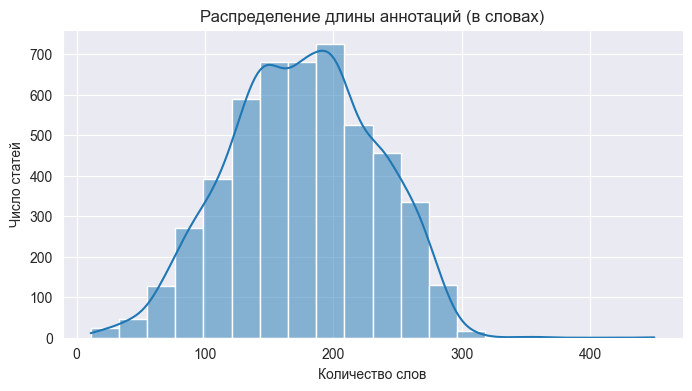

In [124]:
df_articles["abstract_len"] = df_articles["abstract"].apply(lambda x: len(x.split()))

print("Статистика по длине аннотаций:")
print(df_articles["abstract_len"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df_articles["abstract_len"], bins=20, kde=True)
plt.title("Распределение длины аннотаций (в словах)")
plt.xlabel("Количество слов")
plt.ylabel("Число статей")
plt.show()


Так как основная часть статей имеет длину 100-200 слов, то и размеры чанков были взяты не 500, а 100 с перекрытием в 15 слов

In [125]:
def split_into_chunks(text, chunk_size=100, overlap=15):
    assert (chunk_size > 0)
    assert (overlap >= 0)
    assert (overlap < chunk_size)

    words = text.split()
    n = len(words)

    if n == 0:
        return []

    chunks = []
    start = 0

    while start < n:
        end = start + chunk_size
        chunk_words = words[start:end]
        chunks.append(" ".join(chunk_words))

        start += chunk_size - overlap
        if start >= n:
            break

    return chunks


In [126]:
all_chunks = []

for idx, row in df_articles.iterrows():
    article_id = row["id"]
    abstract = row["abstract"]

    chunks = split_into_chunks(abstract)

    for i, ch in enumerate(chunks):
        all_chunks.append({
            "article_id": article_id,
            "chunk_id": f"{article_id}::chunk_{i}",
            "chunk_index": i,
            "chunk_text": ch,
            "chunk_word_count": len(ch.split())
        })

df_chunks = pd.DataFrame(all_chunks)

print(f"Всего чанков: {len(df_chunks)}")
df_chunks.head()

Всего чанков: 12855


,article_id,chunk_id,chunk_index,chunk_text,chunk_word_count
0,http://arxiv.org/abs/2012.14086v1,http://arxiv.org/abs/2012.14086v1::chunk_0,0,The architectural style of microservices has b...,100
1,http://arxiv.org/abs/2012.14086v1,http://arxiv.org/abs/2012.14086v1::chunk_1,1,when the service is available at least 99.999%...,100
2,http://arxiv.org/abs/2012.14086v1,http://arxiv.org/abs/2012.14086v1::chunk_2,2,to the healthy microservice instances by enabl...,58
3,http://arxiv.org/abs/1904.08007v1,http://arxiv.org/abs/1904.08007v1::chunk_0,0,Proteins are the workhorses of life and gainin...,100
4,http://arxiv.org/abs/1904.08007v1,http://arxiv.org/abs/1904.08007v1::chunk_1,1,"a test oracle, which determines passing or fai...",91


Статистика по количеству слов в чанках:
count    12855.000000
mean        77.033061
std         31.795151
min          1.000000
25%         55.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: chunk_word_count, dtype: float64


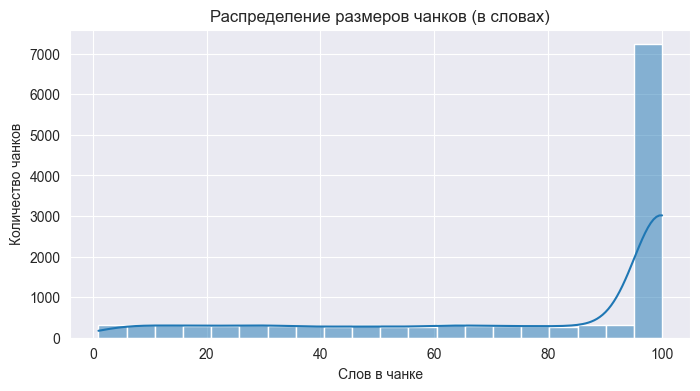

In [127]:
print("Статистика по количеству слов в чанках:")
print(df_chunks["chunk_word_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df_chunks["chunk_word_count"], bins=20, kde=True)
plt.title("Распределение размеров чанков (в словах)")
plt.xlabel("Слов в чанке")
plt.ylabel("Количество чанков")
plt.show()

Статистика по количеству чанков на статью:
count    5000.000000
mean        2.571000
std         0.737745
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: chunk_id, dtype: float64


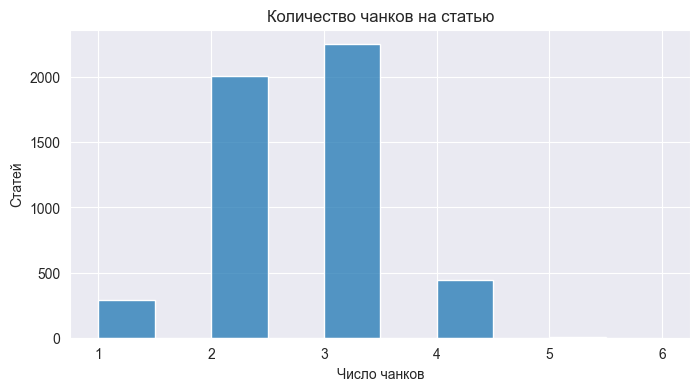

In [128]:
chunks_per_article = df_chunks.groupby("article_id")["chunk_id"].count()

print("Статистика по количеству чанков на статью:")
print(chunks_per_article.describe())

plt.figure(figsize=(8, 4))
sns.histplot(chunks_per_article, bins=10, kde=False)

xmin, xmax = int(chunks_per_article.min()), int(chunks_per_article.max())
plt.xticks(range(xmin, xmax + 1))

plt.title("Количество чанков на статью")
plt.xlabel("Число чанков")
plt.ylabel("Статей")
plt.show()

### Векторизация

In [129]:
%%capture
!pip install sentence-transformers --user

In [130]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Embedding dimension:", embedding_model.get_sentence_embedding_dimension())

Embedding dimension: 384


In [131]:
embeddings = []
for text in tqdm(df_chunks["chunk_text"], desc="Encoding chunks"):
    emb = embedding_model.encode(text)
    embeddings.append(emb)

embeddings = np.vstack(embeddings)

df_chunks["embedding"] = list(embeddings)
df_chunks.head()

Encoding chunks: 100%|██████████| 12855/12855 [02:28<00:00, 86.61it/s]


,article_id,chunk_id,chunk_index,chunk_text,chunk_word_count,embedding
0,http://arxiv.org/abs/2012.14086v1,http://arxiv.org/abs/2012.14086v1::chunk_0,0,The architectural style of microservices has b...,100,"[0.010489311, 0.007830642, 0.013153107, -0.038..."
1,http://arxiv.org/abs/2012.14086v1,http://arxiv.org/abs/2012.14086v1::chunk_1,1,when the service is available at least 99.999%...,100,"[-0.05212534, -0.028175242, 0.035007507, -0.02..."
2,http://arxiv.org/abs/2012.14086v1,http://arxiv.org/abs/2012.14086v1::chunk_2,2,to the healthy microservice instances by enabl...,58,"[-0.05221043, -0.007408566, 0.07447998, -0.005..."
3,http://arxiv.org/abs/1904.08007v1,http://arxiv.org/abs/1904.08007v1::chunk_0,0,Proteins are the workhorses of life and gainin...,100,"[-0.044951964, -0.09348693, 0.024364833, 0.049..."
4,http://arxiv.org/abs/1904.08007v1,http://arxiv.org/abs/1904.08007v1::chunk_1,1,"a test oracle, which determines passing or fai...",91,"[-0.10893837, 0.0040369355, 0.051753268, -0.01..."


#### FAISS

In [132]:
%%capture
!pip install faiss-cpu --user

In [133]:
import faiss

faiss.normalize_L2(embeddings)
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("Кол-во векторов в индексе:", index.ntotal)

Кол-во векторов в индексе: 12855


In [134]:
def search_chunks(query_text, search_index, k=5):
    query_emb = embedding_model.encode(query_text).astype("float32")
    query_emb = query_emb.reshape(1, -1)

    faiss.normalize_L2(query_emb)
    scores, indices = search_index.search(query_emb, k=k)

    found = []
    for idx in indices[0]:
        chunk_row = df_chunks.iloc[idx]

        article_row = df_articles[df_articles["id"] == chunk_row.article_id].iloc[0]

        found.append({
            "chunk_text": chunk_row.chunk_text,
            "article_id": chunk_row.article_id,
            "full_abstract": article_row.abstract
        })

    return {
        "query": query_text,
        "scores": scores[0].tolist(),
        "indices": indices[0].tolist(),
        "chunks": found
    }


In [135]:
query_text = "What is the best programming language?"
result = search_chunks(query_text, index, k=5)

print("QUERY:", result["query"])
print()

for i, (score, chunk) in enumerate(zip(result["scores"], result["chunks"])):
    print(f"result #{i}")
    print("- score:", score)
    print("- id:", chunk["article_id"])
    print("- chunk:", chunk["chunk_text"], "...")
    print()

QUERY: What is the best programming language?

result #0
- score: 0.5783901810646057
- id: http://arxiv.org/abs/2006.01351v1
- chunk: The choice of programming language is a very important decision as it not only affects the performance and maintainability of the software but also dictates the talent pool and community support available. To better understand the trade-offs involved in making such a decision, we define and compute popularity, demand, availability and community engagement of programming languages through online collaboration platforms. We perform our analysis using data from Github and StackOverflow, two of the most popular programming communities. We get data related projects, languages and developer engagement from Github and programming questions with answers along with language tags from StackOverflow. We ...

result #1
- score: 0.5768980979919434
- id: http://arxiv.org/abs/2004.06280v1
- chunk: what Python provides as the alternative to popular technologies offered 

### Интеграция LLM

In [136]:
%%capture
!pip install transformers accelerate sentencepiece --user

In [137]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-large" # flan-t5-base

tokenizer_llm = AutoTokenizer.from_pretrained(model_name)
llm = AutoModelForSeq2SeqLM.from_pretrained(model_name)

In [138]:
def llm_answer(text, max_new_tokens=512):
    inputs = tokenizer_llm(text, truncation=True, return_tensors="pt")
    outputs = llm.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
    )
    return tokenizer_llm.decode(outputs[0], skip_special_tokens=True)


In [139]:
def llm_simple_prompt(query_text, max_new_tokens=512):
    prompt = (
        "You are an software development assistant that answers questions in a clear and accurate way.\n"
        f"Question: {query_text}\n"
        "Answer:"
    )
    return llm_answer(prompt, max_new_tokens=max_new_tokens)


In [140]:
print(llm_answer("How Kafka handles multiple consumers?"))
print(llm_simple_prompt("How Kafka handles multiple consumers?"))

Kafka stores data in a single table
Kafka handles multiple consumers by storing the data in a single table.


### Промпт-инжиниринг и обработка опечаток

#### SymSpell для исправлений

In [141]:
%%capture
!pip install symspellpy --user

In [142]:
import importlib.resources
from itertools import islice

from symspellpy import SymSpell, Verbosity

sym_spell = SymSpell()
dictionary_path = importlib.resources.files("symspellpy") / "frequency_dictionary_en_82_765.txt"
sym_spell.load_dictionary(dictionary_path, 0, 1)

print(list(islice(sym_spell.words.items(), 5)))

[('the', 23135851162), ('of', 13151942776), ('and', 12997637966), ('to', 12136980858), ('a', 9081174698)]


In [143]:
def symspell_correct(query: str) -> str:
    corrected_words = []

    for word in query.split():
        suggestions = sym_spell.lookup(word, Verbosity.TOP, max_edit_distance=2)
        if suggestions:
            corrected_words.append(suggestions[0].term)
        else:
            corrected_words.append(word)

    return " ".join(corrected_words)


In [144]:
test_query = "Find thi best    softwere: arkitecture disign sistem"
print(symspell_correct(test_query))

find the best software architecture design system


#### Промпт-инжиниринг

In [145]:
def rag_query(user_query, search_index, k=5, max_new_tokens=256):
    spell_correct_query = symspell_correct(user_query)

    correction_prompt = (
        "Rewrite the following user query making it more clear, formal, and precise."
        "Do not answer the question. Keep the original meaning of question. Output only the corrected query.\n\n"
        f"User query: {spell_correct_query}\n"
        "Corrected query:"
    )
    llm_corrected_query = llm_answer(correction_prompt, max_new_tokens=64)

    search_result = search_chunks(llm_corrected_query, search_index, k=k)
    chunks = search_result["chunks"]
    context = "\n".join(c["chunk_text"] for c in chunks)

    rag_prompt = (
        "You are a science research assistant. Answer the question based on the context below. Keep the answer short, clear and precise.\n"
        f"Context:\n{context}\n\n"
        f"Question: {llm_corrected_query}\n"
        "Answer:"
    )

    rag_answer = llm_answer(rag_prompt, max_new_tokens=max_new_tokens)

    return {
        "user_query": user_query,
        "corrected_query": llm_corrected_query,
        "rag_prompt": rag_prompt,
        "rag_answer": rag_answer,
    }


In [146]:
query = "whats teh diffrence betwen unit test and integration test?"
result = rag_query(query, index, k=3)

print("User query:", result["user_query"])
print("Corrected query:", result["corrected_query"])
print("RAG answer:", result["rag_answer"])
print()
print("RAG prompt:", result["rag_prompt"])

User query: whats teh diffrence betwen unit test and integration test?
Corrected query: what is the difference between unit test and integration test?
RAG answer: Integration testing plays an important role in revealing issues in interactions among cooperating components.

RAG prompt: You are a science research assistant. Answer the question based on the context below. Keep the answer short, clear and precise.
Context:
Software systems typically consist of various interacting components and units. While these components can be tested and shown to work correctly in isolation, when integrated and start interacting with each other, they may fail to produce the desired behaviors and results. Integration testing plays an important role in revealing issues in interactions among cooperating components. Identifying different interaction scenarios, however, is not a trivial task when performing integration testing. On the other hand, most of the integration testing solutions proposed in the lit

#### Сравнение

In [147]:
test_queries = [
    "whats teh benifits of microservcies over monlithic arcitecture?",
    "how does postgres handle acid transactions internally?",
    "best practics for handlng concurrency in distrbuted systems?",
    "how can code review practices prevent bugs in large software projects?",
    "whats the diffrence betwen unit test and integration test?"
]

for i, q in enumerate(test_queries, 1):
    print("=" * 100)
    print(f"TEST {i}: {q}")
    print("=" * 100)

    print("[1] llm_answer:", llm_answer(q, max_new_tokens=500))

    print("[2] llm_simple_prompt:", llm_simple_prompt(q, max_new_tokens=500))

    rag_res = rag_query(q, index, k=5, max_new_tokens=300)
    print("[3] rag_query:", rag_res["rag_answer"])
    print("Corrected question:", rag_res["corrected_query"])
    print()

TEST 1: whats teh benifits of microservcies over monlithic arcitecture?
[1] llm_answer: a more sustainable and sustainable economy
[2] llm_simple_prompt: a more efficient use of resources
[3] rag_query: fine-grained, loosely coupled services that communicate through lightweight protocols
Corrected question: what are the benefits of microservices over monolithic architecture?

TEST 2: how does postgres handle acid transactions internally?
[1] llm_answer: arithmetic
[2] llm_simple_prompt: a sys.stdin utility
[3] rag_query: respective routines during execution
Corrected question: how does postures handle acid transactions internally?

TEST 3: best practics for handlng concurrency in distrbuted systems?
[1] llm_answer: Using a centralized database
[2] llm_simple_prompt: Using a distributed system
[3] rag_query: D-SCOOP is a distributed programming model that allows for interference-free synchronization of network objects.
Corrected question: What are the best practices for handling concurr

#### Анализ результатов

Благодаря RAG мы получаем более качественные ответы: они становятся ближе к техническим. Базовая модель хоть иногда и дает "подходящие" по смыслу ответы, но также она и промахивается выдавая совсем глупые результаты. При добавлении промпта (даже простого), модель уже начинает давать более осмысленные результаты. А уже при использовании RAG достигаются самые подробные ответы (возможно даже слишком усложненные, но контекст основан на научных статьях, поэтому такой результат и ожидался)